# Hate Speech Classification — Baseline Pipeline
**Step 1: Baseline Model → Step 2: Error Analysis**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

## Data

In [39]:
# # ── 1. Load dataset ──────────────────────────────────────────────
# from datasets import load_dataset
# import pandas as pd
# import re

# dataset = load_dataset("tdavidson/hate_speech_offensive")
# df = dataset["train"].to_pandas()

# # ── 2. Rename kolom biar lebih readable ─────────────────────────
# df = df.rename(columns={
#     "count":                    "annotator_count",
#     "hate_speech_count":        "hate_speech_votes",
#     "offensive_language_count": "offensive_votes",
#     "neither_count":            "neither_votes",
#     "class":                    "label",
#     "tweet":                    "text",
# })

# # ── 3. Map label integer → string ───────────────────────────────
# label_map = {0: "hate_speech", 1: "offensive", 2: "neither"}
# df["label_str"] = df["label"].map(label_map)

# # ── 4. Preprocessing teks ────────────────────────────────────────
# def preprocess_tweet(text):
#     text = str(text)
#     text = re.sub(r"http\S+|www\S+", "", text)          # hapus URL
#     text = re.sub(r"@\w+", "@USER", text)                # anonimkan mention
#     text = re.sub(r"#(\w+)", r"\1", text)                # hapus simbol hashtag, simpan kata
#     text = re.sub(r"RT\s+", "", text)                    # hapus "RT"
#     text = re.sub(r"[^\w\s@'!?.,]", " ", text)          # hapus karakter aneh
#     text = re.sub(r"\s+", " ", text).strip()             # normalisasi whitespace
#     text = text.lower()
#     return text

# df["text_clean"] = df["text"].apply(preprocess_tweet)

# # ── 5. Feature tambahan (opsional tapi useful) ───────────────────
# df["text_length"]  = df["text_clean"].str.len()
# df["word_count"]   = df["text_clean"].str.split().str.len()
# df["has_mention"]  = df["text"].str.contains(r"@\w+", regex=True).astype(int)
# df["has_hashtag"]  = df["text"].str.contains(r"#\w+", regex=True).astype(int)

# # ── 6. Buang duplikat & missing values ───────────────────────────
# df = df.drop_duplicates(subset=["text_clean"])
# df = df.dropna(subset=["text_clean", "label"])
# df = df[df["text_clean"].str.len() > 5]   # filter teks terlalu pendek

# # ── 7. Simpan ke CSV ─────────────────────────────────────────────
# df.to_csv("hate_speech_clean.csv", index=False)

# print(df.shape)
# print(df["label_str"].value_counts())
# print(df.head(3))

In [40]:
df = pd.read_csv('hate_speech_clean.csv')

df = df[["text_clean", "label"]]

print(df["label"].value_counts())
df.head()

label
1    18990
2     4106
0     1406
Name: count, dtype: int64


,text_clean,label
0,!!! @user as a woman you shouldn't complain ab...,2
1,!!!!! @user boy dats cold...tyga dwn bad for c...,1
2,!!!!!!! @user dawg!!!! @user you ever fuck a b...,1
3,!!!!!!!!! @user @user she look like a tranny,1
4,!!!!!!!!!!!!! @user the shit you hear about me...,1


In [41]:
import re

def clean_text(text):
    text = text.lower()                                      # lowercase
    text = re.sub(r'@\w+', '', text)                        # hapus @mention
    text = re.sub(r'http\S+|www\S+', '', text)              # hapus URL
    text = re.sub(r'\bamp\b', '', text)                     # hapus 'amp' (sisa HTML &amp;)
    text = re.sub(r'\b\d{4,}\b', '', text)                  # hapus angka panjang (unicode artifacts)
    text = re.sub(r'[^\w\s]', '', text)                     # hapus punctuation (termasuk !!!)
    text = re.sub(r'\s+', ' ', text).strip()                # normalisasi spasi
    return text

In [42]:
df['clean_tweet'] = df['text_clean'].apply(clean_text)

In [43]:
df

,text_clean,label,clean_tweet
0,!!! @user as a woman you shouldn't complain ab...,2,as a woman you shouldnt complain about cleanin...
1,!!!!! @user boy dats cold...tyga dwn bad for c...,1,boy dats coldtyga dwn bad for cuffin dat hoe i...
2,!!!!!!! @user dawg!!!! @user you ever fuck a b...,1,dawg you ever fuck a bitch and she start to cr...
3,!!!!!!!!! @user @user she look like a tranny,1,she look like a tranny
4,!!!!!!!!!!!!! @user the shit you hear about me...,1,the shit you hear about me might be true or it...
...,...,...,...
24497,you's a muthaf in lie 8220 @user @user @user r...,1,yous a muthaf in lie right his tl is trash now...
24498,"you've gone and broke the wrong heart baby, an...",2,youve gone and broke the wrong heart baby and ...
24499,young buck wanna eat!!.. dat nigguh like i ain...,1,young buck wanna eat dat nigguh like i aint fu...
24500,youu got wild bitches tellin you lies,1,youu got wild bitches tellin you lies


In [44]:
for i, row in df[0:50].iterrows():

    print("Comment :", row["clean_tweet"], '|', row['label'])
    print("-"*50)


Comment : as a woman you shouldnt complain about cleaning up your house as a man you should always take the trash out | 2
--------------------------------------------------
Comment : boy dats coldtyga dwn bad for cuffin dat hoe in the 1st place | 1
--------------------------------------------------
Comment : dawg you ever fuck a bitch and she start to cry you be confused as shit | 1
--------------------------------------------------
Comment : she look like a tranny | 1
--------------------------------------------------
Comment : the shit you hear about me might be true or it might be faker than the bitch who told it to ya | 1
--------------------------------------------------
Comment : the shit just blows meclaim you so faithful and down for somebody but still fucking with hoes | 1
--------------------------------------------------
Comment : i can not just sit up and hate on another bitch i got too much shit going on | 1
--------------------------------------------------
Comment : caus

In [49]:
df = df.drop_duplicates(subset=["clean_tweet"])

In [50]:
# Ganti path ini kalau punya data lebih besar
# df = pd.read_csv("data.csv")  
# df.columns = ["comment", "label"]

# label_map = {"neutral": 0, "offensive": 1, "hateful": 2}
# df["label_id"] = df["label"].map(label_map)

X = df["clean_tweet"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 16898 | Test: 7242


In [51]:
train_set = set(X_train)
test_set = set(X_test)

print(len(train_set.intersection(test_set)))

0


In [53]:
label_map = {0: "hate_speech", 1: "offensive", 2: "neither"}

## Step 1 — Baseline Models

In [54]:
from sklearn.linear_model import SGDClassifier

In [55]:
# tfidf = TfidfVectorizer(
#     ngram_range=(1, 2),
#     min_df=1,
#     max_features=10000,
#     sublinear_tf=True
    
# )


tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

# TfidfVectorizer(
#     analyzer="char_wb",
#     ngram_range=(3,5)
# )

# models = {
#     "LR": LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced"),
#     "LinearSVM": LinearSVC(C=0.5, class_weight="balanced", max_iter=2000),
#     "RF": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
# }

models = {
    "LR": LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight="balanced"
    ),

    "LinearSVM": LinearSVC(
        C=0.5,
        class_weight="balanced",
        max_iter=2000
    ),

    # 🔥 SGD SVM variant
    "SGD_SVM": SGDClassifier(
        loss="hinge",
        penalty="l2",
        alpha=1e-4,
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    # 🔥 SGD Logistic variant
    "SGD_LR": SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-4,
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "RF": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ),
}

pipelines = {
    name: Pipeline([("tfidf", tfidf), ("clf", clf)])
    for name, clf in models.items()
}

results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results[name] = preds
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds, target_names = [
    label_map[0],  # hate_speech
    label_map[1],  # offensive
    label_map[2]   # neither
]))


=== LR ===
              precision    recall  f1-score   support

 hate_speech       0.39      0.54      0.45       415
   offensive       0.96      0.88      0.92      5604
     neither       0.75      0.94      0.83      1223

    accuracy                           0.87      7242
   macro avg       0.70      0.79      0.74      7242
weighted avg       0.89      0.87      0.88      7242


=== LinearSVM ===
              precision    recall  f1-score   support

 hate_speech       0.47      0.36      0.41       415
   offensive       0.94      0.93      0.94      5604
     neither       0.80      0.88      0.84      1223

    accuracy                           0.89      7242
   macro avg       0.74      0.73      0.73      7242
weighted avg       0.89      0.89      0.89      7242


=== SGD_SVM ===
              precision    recall  f1-score   support

 hate_speech       0.46      0.44      0.45       415
   offensive       0.95      0.92      0.93      5604
     neither       0.77    

In [25]:
pipe = pipelines["LR"]
tfidf = pipe.named_steps["tfidf"]

feature_names = tfidf.get_feature_names_out()
print(feature_names[-50:])

['yous hoe' 'youth' 'youtube' 'youtube channel' 'youu' 'youuu' 'youve'
 'youve been' 'youve ever' 'youve got' 'youve gotta' 'youve made'
 'youve never' 'yr' 'yr old' 'yrs' 'yrs ago' 'ysrahal' 'yu' 'yu aint'
 'yuck' 'yuh' 'yuhh' 'yuhhh' 'yuhhhh' 'yun' 'yung' 'yung berg'
 'yung nicca' 'yung nigga' 'yup' 'ze' 'zebra' 'zebras' 'zero'
 'zero bitches' 'zich' 'zimmerman' 'zip' 'zo' 'zoe' 'zog' 'zombie'
 'zombies' 'zone' 'zone bitch' 'zonenn' 'zonenn want' 'zoo' 'zoom']


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

# 🔥 TF-IDF yang lebih optimal
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

# 🔥 Base models
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight="balanced"
)

sgd_svm = SGDClassifier(
    loss="hinge",
    penalty="l2",
    alpha=1e-4,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# 🔥 Ensemble (HARD voting)
ensemble = Pipeline([
    ("tfidf", tfidf),
    ("clf", VotingClassifier(
        estimators=[
            ("lr", lr),
            ("sgd_svm", sgd_svm)
        ],
        voting="hard",
        weights=[2, 1]   # 🔥 LR lebih dominan
    ))
])

# Train
ensemble.fit(X_train, y_train)

# Predict
y_pred = ensemble.predict(X_test)

# Evaluate
print("=== Ensemble (LR + SGD_SVM) ===")
print(classification_report(
    y_test,
    y_pred,
    labels=[0,1,2],
    target_names=["hate_speech", "offensive", "neither"]
))

=== Ensemble (LR + SGD_SVM) ===
              precision    recall  f1-score   support

 hate_speech       0.39      0.54      0.45       422
   offensive       0.96      0.89      0.92      5697
     neither       0.76      0.93      0.84      1232

    accuracy                           0.88      7351
   macro avg       0.70      0.79      0.74      7351
weighted avg       0.90      0.88      0.88      7351



In [56]:
from sentence_transformers import SentenceTransformer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# 🔥 Load embedding model
model_emb = SentenceTransformer('all-MiniLM-L6-v2')

# 🔥 Encode text
X_train_emb = model_emb.encode(
    X_train.tolist(),
    batch_size=32,
    show_progress_bar=True
)

X_test_emb = model_emb.encode(
    X_test.tolist(),
    batch_size=32,
    show_progress_bar=True
)

# 🔥 IMPORTANT: scaling embedding
scaler = StandardScaler()
X_train_emb = scaler.fit_transform(X_train_emb)
X_test_emb = scaler.transform(X_test_emb)

# 🔥 STRONG classifier for embedding space
clf = LinearSVC(
    class_weight="balanced",
    C=1.0
)

# Train
clf.fit(X_train_emb, y_train)

# Predict
y_pred = clf.predict(X_test_emb)

# Evaluate
print(classification_report(
    y_test,
    y_pred,
    target_names=["hate_speech", "offensive", "neither"]
))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/529 [00:00<?, ?it/s]

Batches:   0%|          | 0/227 [00:00<?, ?it/s]

              precision    recall  f1-score   support

 hate_speech       0.36      0.49      0.41       415
   offensive       0.95      0.89      0.92      5604
     neither       0.76      0.87      0.81      1223

    accuracy                           0.87      7242
   macro avg       0.69      0.75      0.72      7242
weighted avg       0.88      0.87      0.87      7242



In [59]:
from sentence_transformers import SentenceTransformer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# 🔥 Load embedding model
model_emb = SentenceTransformer('all-mpnet-base-v2')
# 🔥 Encode text
X_train_emb = model_emb.encode(
    X_train.tolist(),
    batch_size=32,
    show_progress_bar=True
)

X_test_emb = model_emb.encode(
    X_test.tolist(),
    batch_size=32,
    show_progress_bar=True
)

# 🔥 IMPORTANT: scaling embedding
scaler = StandardScaler()
X_train_emb = scaler.fit_transform(X_train_emb)
X_test_emb = scaler.transform(X_test_emb)

# 🔥 STRONG classifier for embedding space
clf = LinearSVC(
    class_weight="balanced",
    C=1.0
)

# Train
clf.fit(X_train_emb, y_train)

# Predict
y_pred = clf.predict(X_test_emb)

# Evaluate
print(classification_report(
    y_test,
    y_pred,
    target_names=["hate_speech", "offensive", "neither"]
))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/529 [00:00<?, ?it/s]

Batches:   0%|          | 0/227 [00:00<?, ?it/s]

              precision    recall  f1-score   support

 hate_speech       0.36      0.51      0.42       415
   offensive       0.95      0.89      0.92      5604
     neither       0.77      0.86      0.81      1223

    accuracy                           0.87      7242
   macro avg       0.69      0.75      0.72      7242
weighted avg       0.88      0.87      0.87      7242



In [58]:
import torch
import numpy as np
import pandas as pd
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# 1. CONFIG
# ============================================================
MODEL_NAME = "Hate-speech-CNERG/dehatebert-mono-english"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 4
LR = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL2ID = {"hate_speech": 0, "offensive": 1, "neither": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print(f"Using device: {DEVICE}")

# ============================================================
# 2. DATASET CLASS
# ============================================================
class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ============================================================
# 3. LOAD TOKENIZER & MODEL
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True  # karena original model punya label berbeda
)
model.to(DEVICE)

# ============================================================
# 4. HANDLE CLASS IMBALANCE — Weighted Loss
# ============================================================
# Asumsikan y_train sudah dalam bentuk integer (0, 1, 2)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"Class weights: {class_weights}")
# Expected: hate_speech >> offensive karena imbalance

# ============================================================
# 5. DATALOADER
# ============================================================
train_dataset = HateSpeechDataset(
    X_train.tolist(), y_train.tolist(), tokenizer, MAX_LEN
)
test_dataset = HateSpeechDataset(
    X_test.tolist(), y_test.tolist(), tokenizer, MAX_LEN
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# ============================================================
# 6. OPTIMIZER + SCHEDULER
# ============================================================
# Best practice: different LR untuk backbone vs classifier head
optimizer = AdamW([
    {"params": model.bert.parameters(), "lr": 2e-5},       # backbone: LR kecil
    {"params": model.classifier.parameters(), "lr": 1e-4}  # head: LR lebih besar
], weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,  # 10% warmup
    num_training_steps=total_steps
)

# ============================================================
# 7. TRAINING LOOP
# ============================================================
def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)  # pakai weighted loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping

        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels


# ============================================================
# 8. RUN TRAINING
# ============================================================
best_f1 = 0
best_model_state = None

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    preds, labels = eval_epoch(model, test_loader)

    report = classification_report(
        labels, preds,
        target_names=["hate_speech", "offensive", "neither"],
        output_dict=True
    )
    macro_f1 = report["macro avg"]["f1-score"]

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(labels, preds, target_names=["hate_speech", "offensive", "neither"]))

    # Save best model berdasarkan macro F1
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_model_state = model.state_dict().copy()
        print(f"  ✅ Best model saved! F1: {best_f1:.4f}")

# ============================================================
# 9. SAVE MODEL
# ============================================================
model.load_state_dict(best_model_state)
model.save_pretrained("./dehatebert-finetuned")
tokenizer.save_pretrained("./dehatebert-finetuned")
print("\nModel saved to ./dehatebert-finetuned")

Using device: cuda


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/152 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


pytorch_model.bin:   0%|          | 0.00/669M [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

## Step 2 — Error Analysis
Bagian ini yang paling penting di seluruh pipeline.

In [47]:
# Pilih model utama untuk analisis error
MAIN_MODEL = "LR"
best_pipe = pipelines[MAIN_MODEL]
test_preds = results[MAIN_MODEL]

id_to_label = {v: k for k, v in label_map.items()}

error_df = pd.DataFrame({
    "comment": X_test.values,
    "true": [id_to_label[i] for i in y_test.values],
    "pred": [id_to_label[i] for i in test_preds],
})
error_df["correct"] = error_df["true"] == error_df["pred"]
errors = error_df[~error_df["correct"]]

print(f"Total errors: {len(errors)} / {len(error_df)}")
errors

Total errors: 980 / 7351


,comment,true,pred,correct
9,isnt it funny that the people who call me fat ...,offensive,neutral,False
11,that pic is now circulated by jihadis with a c...,neutral,hateful,False
14,the microwave at work is broken so my ghetto a...,offensive,hateful,False
24,as always eli has the stupid hick hayseed look...,neutral,hateful,False
27,only white trash watch hockey,offensive,neutral,False
...,...,...,...,...
7332,you a shoulda coulda woulda ass niggah ima wis...,offensive,neutral,False
7333,you styl gotta get dem tweets off my nig,neutral,offensive,False
7338,if i ever saw kendall jones in person id kill ...,offensive,neutral,False
7345,yall niggers have a good thanksgiving,offensive,neutral,False


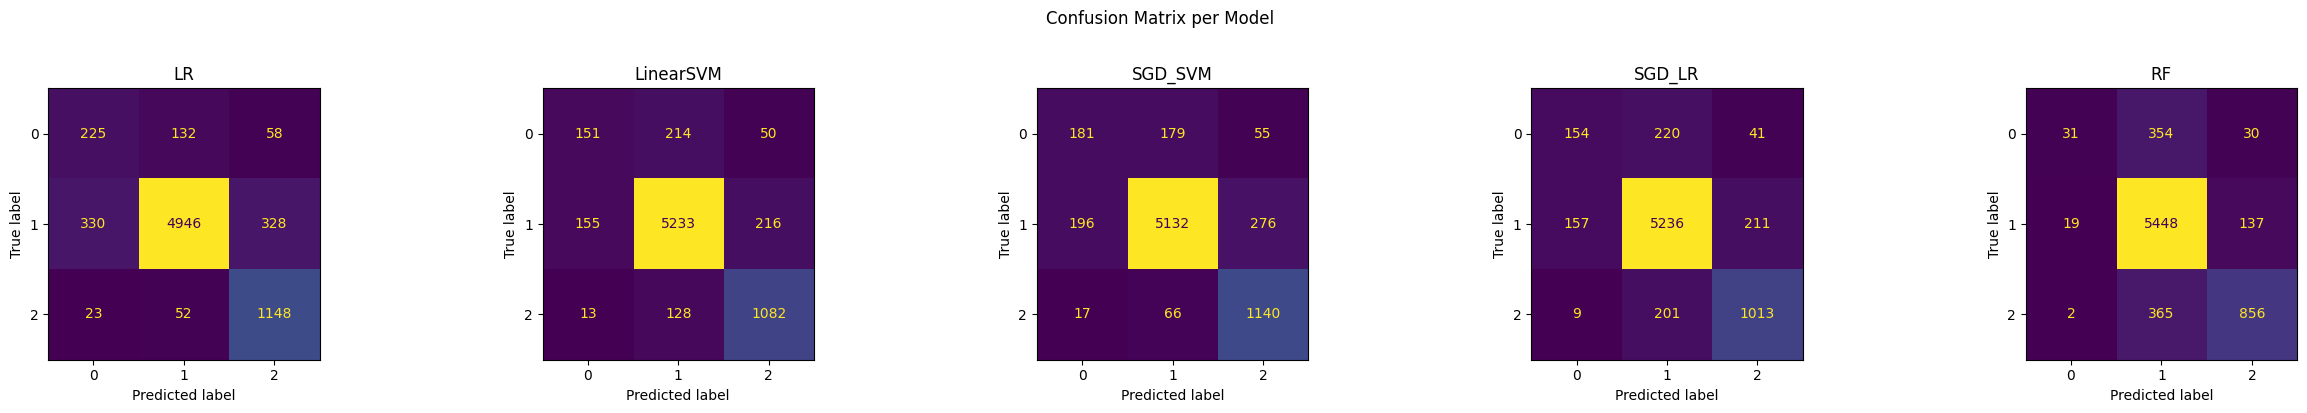

In [57]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_map.keys())
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle("Confusion Matrix per Model", y=1.02)
plt.tight_layout()
plt.show()

In [49]:
# False positive hateful — model bilang hateful padahal bukan
fp_hateful = error_df[(error_df["pred"] == "hateful") & (error_df["true"] != "hateful")]
print("False Positive Hateful (prediksi hateful, aslinya bukan):")
print(fp_hateful[["comment", "true", "pred"]].to_string(index=False))
print()

False Positive Hateful (prediksi hateful, aslinya bukan):
                                                                                                                                  comment      true    pred
                                                           that pic is now circulated by jihadis with a call to kill him saudi isis syria   neutral hateful
                                      the microwave at work is broken so my ghetto ass put a hamburger patty in the toaster to warm it up offensive hateful
                                      as always eli has the stupid hick hayseed look on his face giants fans kill yaselves its gonna be a   neutral hateful
                                                                                                        killin in tekken 6 lies you trash offensive hateful
                                           having a new boyfriend every month doesnt mean youre gorgeous it means youre easy and retarded offensive hateful
      

In [50]:
# False negative offensive — model gagal tangkap offensive
fn_offensive = error_df[(error_df["true"] == "offensive") & (error_df["pred"] != "offensive")]
print("False Negative Offensive (aslinya offensive, prediksi lain):")
print(fn_offensive[["comment", "true", "pred"]].to_string(index=False))
print()

False Negative Offensive (aslinya offensive, prediksi lain):
                                                                                                                                   comment      true    pred
                        isnt it funny that the people who call me fat ugly a whore stupid a cunt a bitch etc are the same ones whining abo offensive neutral
                                       the microwave at work is broken so my ghetto ass put a hamburger patty in the toaster to warm it up offensive hateful
                                                                                                             only white trash watch hockey offensive neutral
                                                                                                         killin in tekken 6 lies you trash offensive hateful
                                            having a new boyfriend every month doesnt mean youre gorgeous it means youre easy and retarded offensive hatef

In [51]:
# Confusion neutral vs offensive
neu_off = error_df[
    ((error_df["true"] == "neutral") & (error_df["pred"] == "offensive")) |
    ((error_df["true"] == "offensive") & (error_df["pred"] == "neutral"))
]
print("Confusion neutral vs offensive:")
print(neu_off[["comment", "true", "pred"]].to_string(index=False))

Confusion neutral vs offensive:
                                                                                                                                   comment      true      pred
                        isnt it funny that the people who call me fat ugly a whore stupid a cunt a bitch etc are the same ones whining abo offensive   neutral
                                                                                                             only white trash watch hockey offensive   neutral
                                                                                                                     bitch u ugly then hoe   neutral offensive
                                                                    everybody got some to say everybody hate if you ask me every bitch gay offensive   neutral
                        hey dis angry white man called me a nigger when i didnt answer da door on time he aint fit to be delivering pizzas offensive   neutral
              

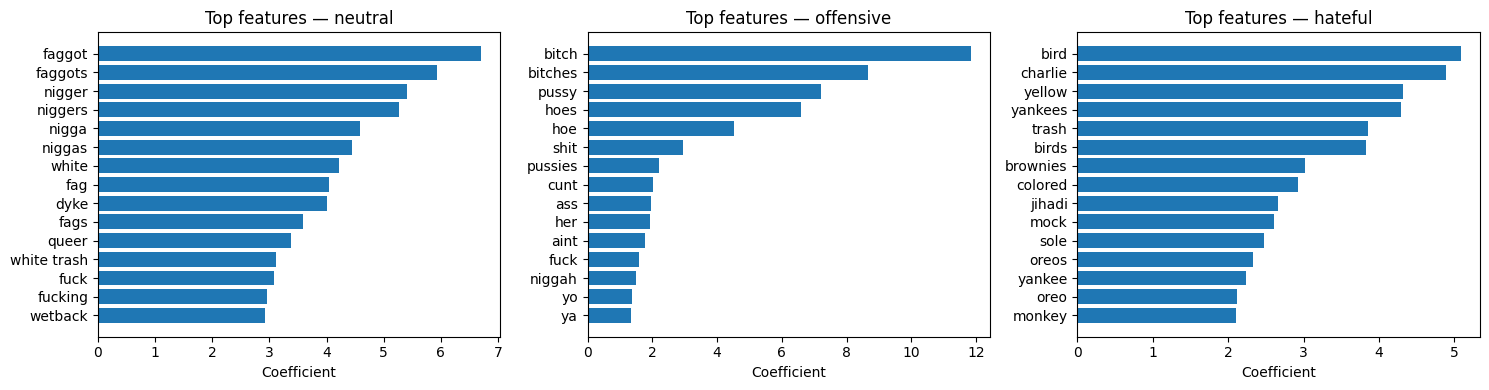

In [52]:
# Top TF-IDF features per class (hanya LR karena coef tersedia)
lr_clf = pipelines["LR"].named_steps["clf"]
feature_names = pipelines["LR"].named_steps["tfidf"].get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (label, ax) in enumerate(zip(label_map.keys(), axes)):
    coef = lr_clf.coef_[i]
    top_idx = np.argsort(coef)[-15:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    top_vals = coef[top_idx]
    ax.barh(top_words[::-1], top_vals[::-1])
    ax.set_title(f"Top features — {label}")
    ax.set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

In [53]:
# Error breakdown by error type
error_summary = (
    errors.groupby(["true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print("Error Summary:")
print(error_summary.to_string(index=False))

Error Summary:
     true      pred  count
offensive   neutral    424
offensive   hateful    295
  neutral offensive    132
  neutral   hateful     53
  hateful offensive     48
  hateful   neutral     28
